In [1]:
import IPython
import os
notebook_path = "/".join(
        IPython.extract_module_locals()[1]["__vsc_ipynb_file__"].split("/")
    )
notebook_dir = os.path.dirname(os.path.abspath(notebook_path))
os.chdir(notebook_dir)
os.chdir('../../../')
!pwd

/Users/vipin/BHT - Data Science/CalgoLab/BGR


In [2]:
import sqlite3
import pandas as pd

db_path = '../data/BGR/sqlite/database_soilnet-study_04-12-25.db'
table = 'predictions'

if os.path.exists(db_path):
    print(f"Database found at {db_path}")
else:
    raise FileNotFoundError(f"Database not found at {db_path}")

with sqlite3.connect(db_path) as conn:
    df = pd.read_sql(f"SELECT * FROM {table}", conn, index_col='id')
    
    df['time_stamp'] = pd.to_datetime(df['time_stamp']) # Convert timestamp to datetime
    
    df['skipped'] = df['skipped'].astype(bool) # Convert skipped to integer
    
    df["image_name"] = df["image_path"].apply(lambda x: os.path.basename(x)) # Extract image name from path
    
    df['depths'] = df['depths'].apply(lambda x: x.replace('[', '').replace(']', '').split(',') if pd.notnull(x) else []) # Split depths into list
    df['depths'] = df['depths'].apply(lambda lst: [float(i) if i != '' else None for i in lst]) # Convert depths to float
    df['depths'] = df['depths'].apply(lambda lst: [d for d in lst if d is not None]) # Remove None values
    
    df['symbols'] = df['symbols'].apply(lambda x: x.replace('[', '').replace(']', '').split(',') if pd.notnull(x) else []) # Split symbols into list
    df['symbols'] = df['symbols'].apply(lambda lst: [s.strip().strip("'").strip('"')for s in lst]) # Clean symbols
    
    df = df[['time_stamp', 'image_idx', 'image_name', 'anonId', 'skipped', 'depths', 'symbols']] # Reorder columns

display(df.head())

Database found at ../data/BGR/sqlite/database_soilnet-study_04-12-25.db


,time_stamp,image_idx,image_name,anonId,skipped,depths,symbols
id,,,,,,,
1,2025-11-05 09:52:27.765994,483,RP_3343_Y_2.JPG,4bfccfa8-02f8-4ffe-907c-35e836fe46b1,False,"[0.1795454545454546, 0.5909090909090916]","[Ah, Al-Sw, Bt-Sd]"
5,2025-11-05 14:05:06.900418,316,NI_0439_Y_1.JPG,4bfccfa8-02f8-4ffe-907c-35e836fe46b1,False,"[0.3590909090909091, 0.6545454545454549]","[Ap, Bsh, Bsh]"
6,2025-11-06 05:38:50.260315,483,RP_3343_Y_2.JPG,bedaf05b-d9c4-4566-8b5c-832269dd9a12,False,"[0.19772727272727272, 0.5681818181818182]","[Ap, Sw, Bv-Sd]"
7,2025-11-06 05:38:59.609002,316,NI_0439_Y_1.JPG,bedaf05b-d9c4-4566-8b5c-832269dd9a12,True,[],[?]
8,2025-11-06 05:39:52.854213,147,BY_4531_Y_1.JPG,bedaf05b-d9c4-4566-8b5c-832269dd9a12,False,"[0.20909090909090908, 0.6181818181818182]","[Ap, Bv, Bv-Cv]"


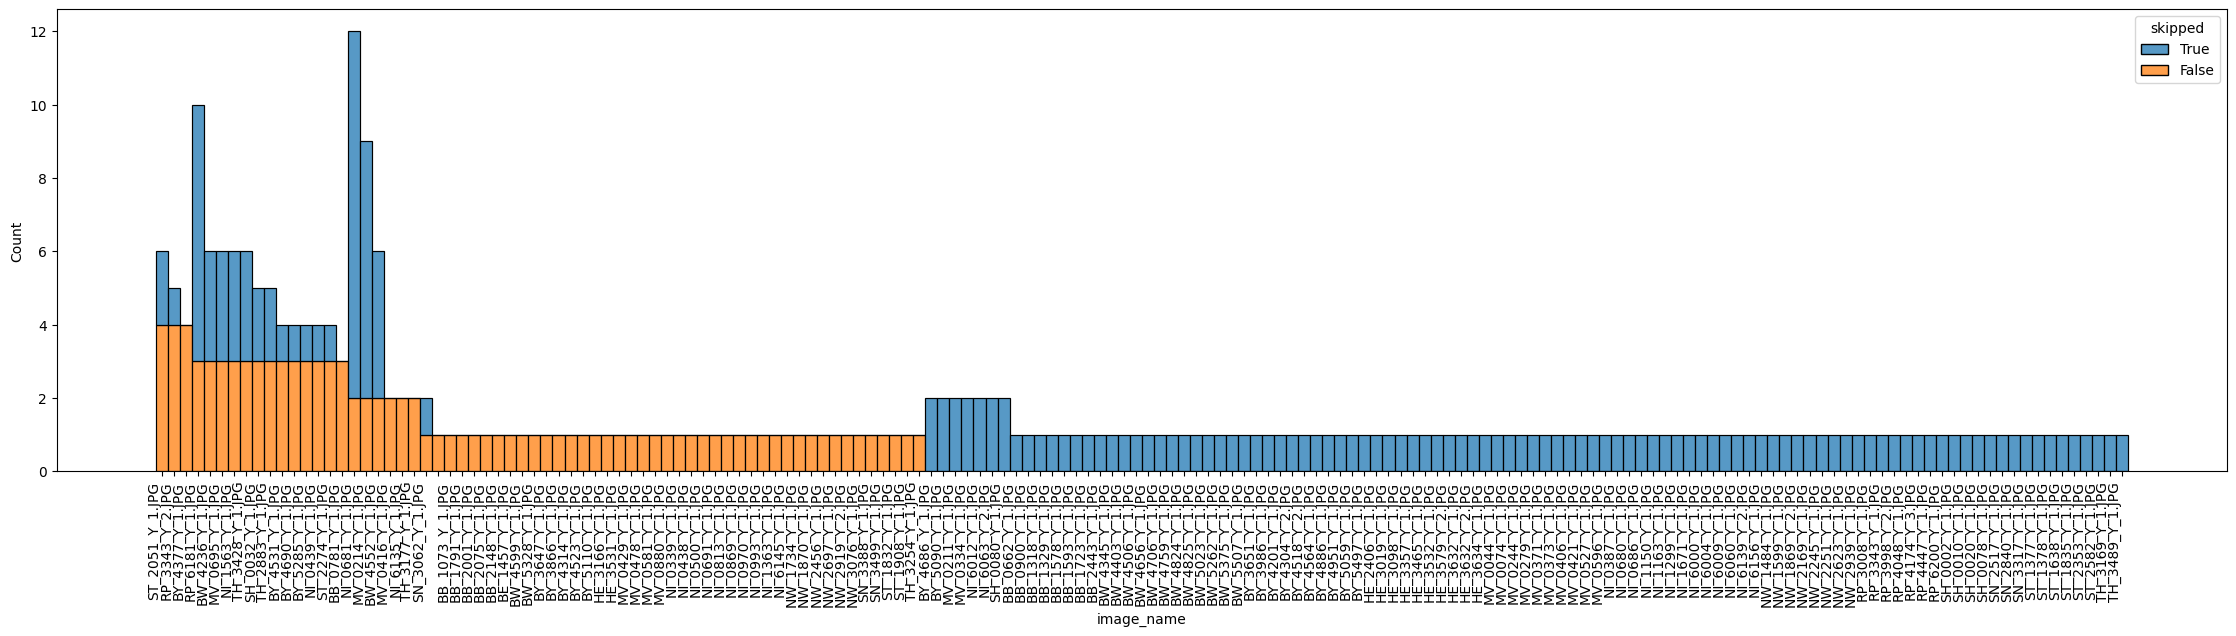

Number of images: 164
Distribution (non-skipped count -> #images):
False
0    100
1     42
2      6
3     13
4      3
Name: count, dtype: int64


In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(28, 6))
# rotate x-axis labels for better readability
plt.xticks(rotation=90, ha='right')
order = df.loc[~df['skipped'], 'image_name'].value_counts().sort_values(ascending=False).index.tolist()
# compute counts per image_name for both hue values
counts = df.groupby(['image_name', 'skipped']).size().unstack(fill_value=0)

# ensure columns exist
prim = counts[False] if False in counts.columns else pd.Series(0, index=counts.index)
sec = counts[True] if True in counts.columns else pd.Series(0, index=counts.index)

# sort by primary (non-skipped) descending, then by secondary (skipped) descending
order = sorted(counts.index, key=lambda n: (-int(prim.loc[n]), -int(sec.loc[n])))

# append any remaining names preserving original uniqueness
order += [n for n in df['image_name'].unique() if n not in order]
df['image_name'] = pd.Categorical(df['image_name'], categories=order, ordered=True)
sns.histplot(data=df, x='image_name', hue='skipped', multiple='stack', hue_order=[True, False])
plt.show()

# distribution of number of non-skipped annotations per image_name
dist = prim.value_counts().sort_index()
print("Number of images:", prim.size)
print("Distribution (non-skipped count -> #images):")
print(dist)

In [4]:
# image names with exactly 3 non-skipped annotations (uses existing `prim`)
img_names_3 = prim[prim == 3].index.tolist()

print(f"Images with 3 non-skipped annotations: {len(img_names_3)}")

# all rows for those images
df_3_non_skipped = df[df['image_name'].isin(img_names_3) & (~df['skipped'])].sort_values(['image_name', 'time_stamp'])
display(df_3_non_skipped)

Images with 3 non-skipped annotations: 13


,time_stamp,image_idx,image_name,anonId,skipped,depths,symbols
id,,,,,,,
42,2025-11-06 14:37:10.481752,513,RP_6181_Y_1.JPG,89138847-ac09-4a58-9912-b308d7ac5f7f,False,"[0.2318181818181818, 0.39090909090909093]","[Ah, M., ilC-Bv]"
163,2025-11-17 08:09:21.480204,513,RP_6181_Y_1.JPG,52f0815d-26b9-4973-8074-97f587625f8a,False,[],[Go]
177,2025-11-19 09:39:30.578228,513,RP_6181_Y_1.JPG,729f9836-70b7-4119-b4b7-f0d9d3e3702b,False,"[0.21363636363636437, 0.4409090909090909]","[M., Ah, ilC]"
41,2025-11-06 14:35:16.690107,48,BW_4236_Y_1.JPG,89138847-ac09-4a58-9912-b308d7ac5f7f,False,"[0.10227272727272728, 0.2681818181818182, 0.65...","[Ah, Ap, Bv-Al, Bt]"
88,2025-11-07 08:13:25.912099,48,BW_4236_Y_1.JPG,5cfcc301-8fda-40ee-967e-7655283c8cd4,False,"[0.22272727272727272, 0.7431818181818182]","[Ap, Sw-Bv, Sd-ilC]"
113,2025-11-10 13:58:47.357531,48,BW_4236_Y_1.JPG,4bfccfa8-02f8-4ffe-907c-35e836fe46b1,False,"[0.24772727272727277, 0.7499999999999998]","[Ap, Bv, Cv]"
93,2025-11-07 08:18:22.364563,304,MV_0695_Y_1.JPG,5cfcc301-8fda-40ee-967e-7655283c8cd4,False,"[0.2545454545454545, 0.30227272727272725, 0.34...","[Ap, Bsh, Bhs, Bsv, Go, Gor]"
166,2025-11-17 08:11:13.016945,304,MV_0695_Y_1.JPG,52f0815d-26b9-4973-8074-97f587625f8a,False,[],[Bhs]
171,2025-11-18 15:59:48.721863,304,MV_0695_Y_1.JPG,89138847-ac09-4a58-9912-b308d7ac5f7f,False,"[0.2681818181818182, 0.33636363636363636, 0.46...","[Aep, Bsh, Bs, Go, Gr]"


In [5]:
import numpy as np
import torch
from torchvision import transforms
from PIL import Image

import sys
sys.path.append('./BGR')

from bgr.soil.modelling.soilnet import SoilNet_LSTM
from bgr.soil.data.horizon_tabular_data import HorizonDataProcessor
from bgr.soil.data.datasets import ImageTabularEnd2EndDataset
import bgr.soil.conformal as bgr_conform

IMAGE_PATH_COLUMN = 'file'
DEPTHS_COLUMN = 'Untergrenze'
LABELS_COLUMN = 'Horizontsymbol_relevant'

dataprocessor = HorizonDataProcessor(label_embeddings_path='BGR/label_embeddings/all_horizons_embeddings_thirds.pickle')
all_horizon_data = dataprocessor.load_processed_data()
_, _, test_data = dataprocessor.multi_label_stratified_shuffle_split(
    all_horizon_data,
    train_val_test_frac=[0.6, 0.2, 0.2], # Dont change this!
    random_state=2025 # Dont change this!
)

test_data.reset_index(drop=True, inplace=True)

In [6]:
import pickle

class Predictions_Interface:
    def __init__(self, preds_pickle):        
        with open(preds_pickle, 'rb') as f:
            preds_dict = pickle.load(f)
            # {
            #     'segment_geotemp_features_test': segment_geotemp_features_test,
            #     'all_pred_depths_test': all_pred_depths_test,
            #     'all_true_depths_test': all_true_depths_test,
            #     'all_pred_logits_test': all_pred_logits_test,
            #     'all_true_hor_inds_test': all_true_hor_inds_test
            # }
        
        segment_geotemp_features_test = preds_dict['segment_geotemp_features_test']
        all_pred_depths_test = preds_dict['all_pred_depths_test']
        all_true_depths_test = preds_dict['all_true_depths_test']
        all_pred_logits_test = preds_dict['all_pred_logits_test']
        all_true_hor_inds_test = preds_dict['all_true_hor_inds_test']
        
        # Concatenattions/Aggregations
        self.all_true_depths_test = np.concatenate(all_true_depths_test, axis=0)
        self.all_pred_depths_test = np.concatenate(all_pred_depths_test, axis=0)

        segment_geotemp_list_test = [item for sublist in segment_geotemp_features_test for item in sublist]
        self.trimmed_true_depths_stacked_test, \
            self.trimmed_pred_depths_stacked_test, \
                segment_geotemp_concat_test   = bgr_conform.trim_concat(self.all_true_depths_test, self.all_pred_depths_test, segment_geotemp_list_test)
        
        self.all_true_hor_inds_test = torch.from_numpy(np.concatenate(all_true_hor_inds_test, axis=0))
        all_pred_logits_test = torch.from_numpy(np.concatenate(all_pred_logits_test, axis=0))
        self.all_pred_hor_inds_test = np.argmax(all_pred_logits_test, axis=1)
        
    def get_trues_and_preds_by_imgpath(self, img_path):
        ex_ind = test_data.index[test_data[IMAGE_PATH_COLUMN] == img_path].tolist()[0]
        print(ex_ind)
        
        # Get index of the stop token of the chosen example
        stop_token_occurrences = (self.trimmed_true_depths_stacked_test == 1.0).nonzero(as_tuple=True)[0]
        top_ind, bottom_ind = stop_token_occurrences[ex_ind-1]+1 if ex_ind > 0 else 0, stop_token_occurrences[ex_ind]+1
        print(top_ind, bottom_ind)
        
        pred_depths = self.trimmed_pred_depths_stacked_test[top_ind:bottom_ind].cpu().numpy()
        pred_hor_inds = self.all_pred_hor_inds_test[top_ind:bottom_ind].cpu().numpy()
        pred_symbols = [dataprocessor.embeddings_dict['ind2label'][ind] for ind in pred_hor_inds] # type: ignore
        
        true_depths = self.trimmed_true_depths_stacked_test[top_ind:bottom_ind].cpu().numpy()
        true_hor_inds = self.all_true_hor_inds_test[top_ind:bottom_ind].cpu().numpy()
        true_symbols = [dataprocessor.embeddings_dict['ind2label'][ind] for ind in true_hor_inds] # type: ignore
        
        # Alignment with the user annotation:
        if pred_depths[-1] == 1.0:
            pred_depths = pred_depths[:-1]
        if true_depths[-1] == 1.0:
            true_depths = true_depths[:-1]
        
        print("Predictions:")
        print(pred_depths)
        print(pred_symbols)
        print("Ground Truths:")
        print(true_depths)
        print(true_symbols)
        # pred_depths = pred_depths[pred_depths != 1.0]
        # pred_symbols = pred_symbols[:len(pred_depths) + 1]
        
        # true_depths = true_depths[true_depths != 1.0]
        # true_symbols = true_symbols[:len(true_depths) + 1]
        
        return pred_depths, pred_symbols, true_depths, true_symbols
        

203
tensor(841) tensor(846)
Predictions:
[0.14968064 0.351156   0.56929713 0.7919736 ]
['Ah', 'Ap', 'Sw-Bv', 'Sd', 'Sd']
Ground Truths:
[0.09 0.38 0.52 0.76]
['Ah', 'Ap', 'Al-Bv', 'Btv', 'Sd']


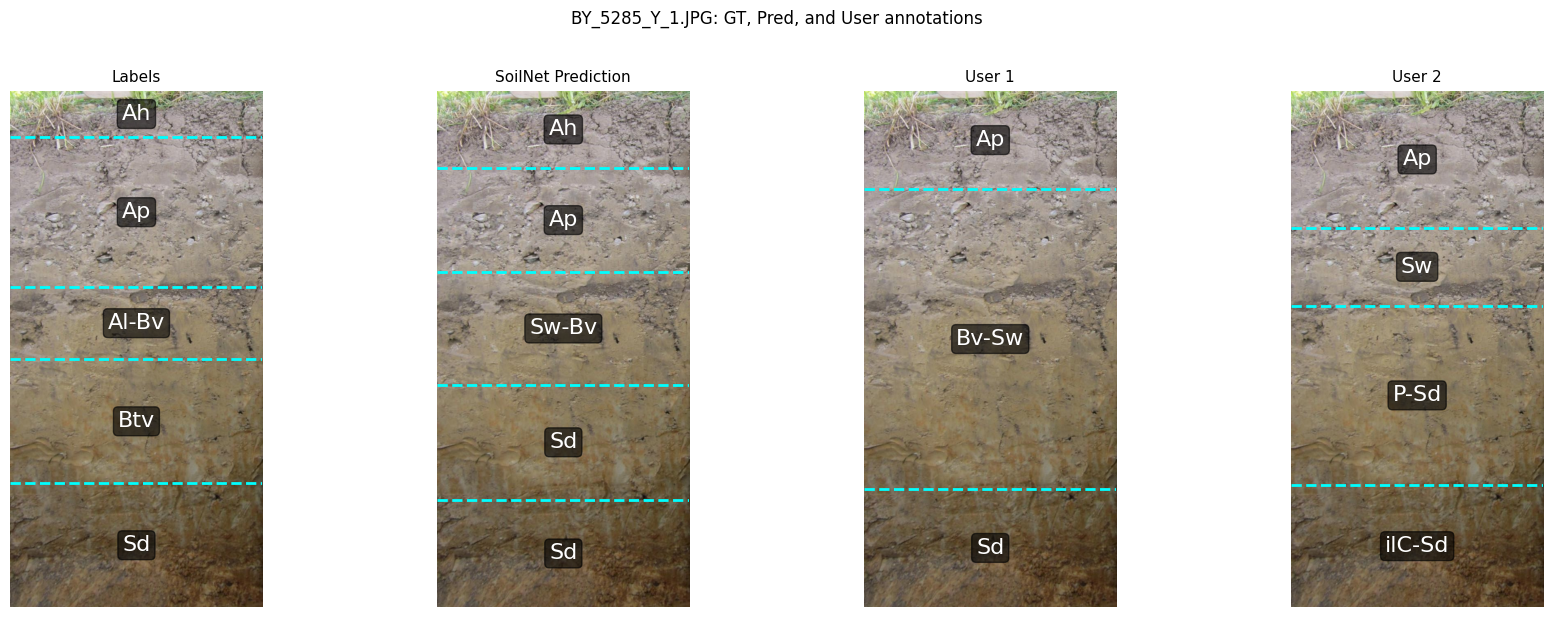

Saved: sample_images/labels_BY_5285_Y_1.jpg
Saved: sample_images/soilnet_prediction_BY_5285_Y_1.jpg
Saved: sample_images/user_1_BY_5285_Y_1.jpg
Saved: sample_images/user_2_BY_5285_Y_1.jpg
304
tensor(1235) tensor(1240)
Predictions:
[0.20063286 0.43940327 0.66551983 0.8718983 ]
['Ap', 'Ap', 'Go', 'Go', 'Go']
Ground Truths:
[0.4  0.53 0.73 0.97]
['Ap', 'Bhs', 'Go', 'Go', 'Gor']


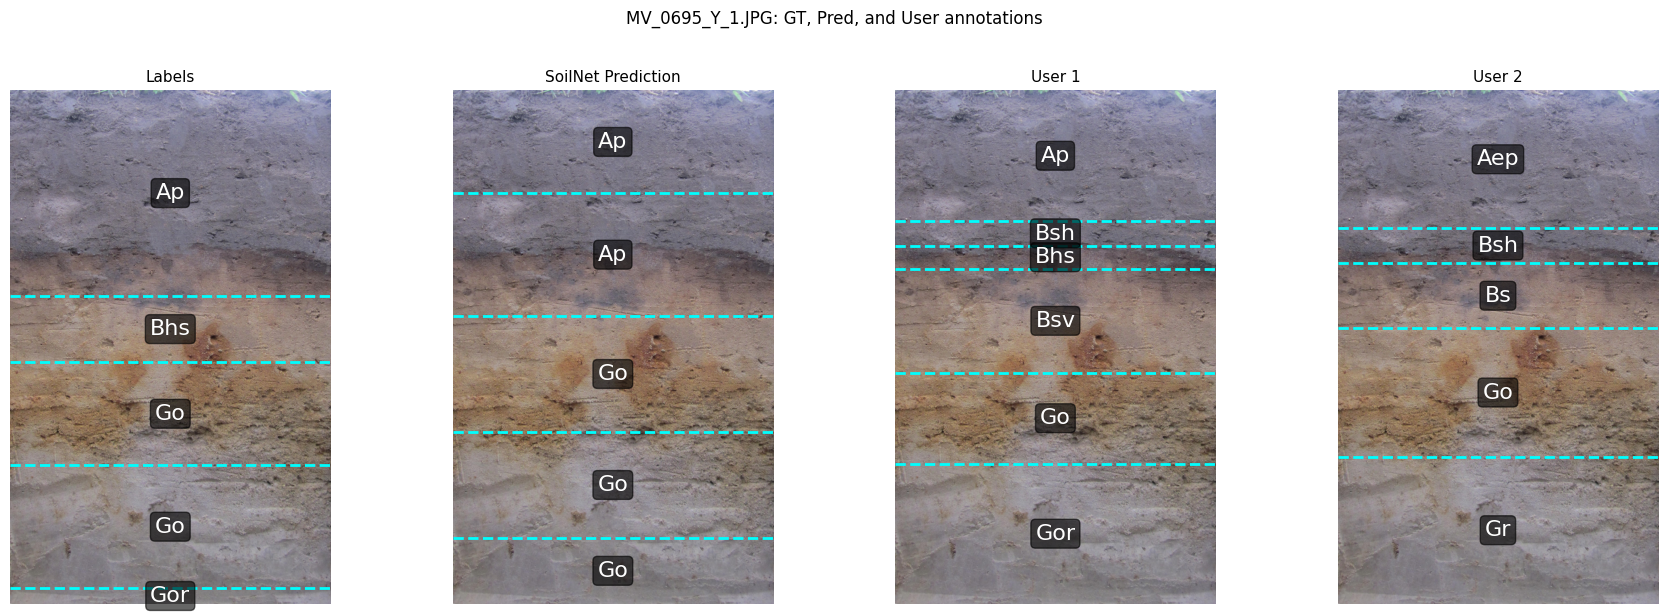

Saved: sample_images/labels_MV_0695_Y_1.jpg
Saved: sample_images/soilnet_prediction_MV_0695_Y_1.jpg
Saved: sample_images/user_1_MV_0695_Y_1.jpg
Saved: sample_images/user_2_MV_0695_Y_1.jpg


In [68]:
predictions_and_trues_interface = Predictions_Interface("predictions_test.pickle")

import matplotlib.pyplot as plt
from PIL import Image

def plot_annotation(ax, img, depths, symbols, title=None):
    w, h = img.size
    y_lines = sorted(float(d) * h for d in depths)
    ax.imshow(img)
    ax.axis("off")
    if title:
        ax.set_title(title, fontsize=11)

    # boundary lines
    for y in y_lines:
        ax.axhline(y, color="cyan", lw=2, ls="--")

    # segment centers + labels
    boundaries = [0.0] + y_lines + [h]
    centers = [(a + b) / 2 for a, b in zip(boundaries[:-1], boundaries[1:])]
    for y, sym in zip(centers, symbols):
        ax.text(
            w / 2,
            y,
            sym,
            ha="center",
            va="center",
            color="white",
            fontsize=16,
            bbox=dict(facecolor="black", alpha=0.6, boxstyle="round,pad=0.2"),
        )

image_folder_path = "../data/BGR/Profilbilder_no_ruler_no_sky"

for img_name in ("BY_5285_Y_1.JPG", "MV_0695_Y_1.JPG"):
    subset = df_3_non_skipped[df_3_non_skipped["image_name"] == img_name]
    if subset.empty:
        continue

    img_path = os.path.join(image_folder_path, img_name)
    if not os.path.exists(img_path):
        print(f"Image not found: {img_path}")
        continue

    # preds/truths; returns preds first, then truths
    pred_depths, pred_symbols, true_depths, true_symbols = (
        predictions_and_trues_interface.get_trues_and_preds_by_imgpath(img_path)
    )

    tracks = [
        ("Labels", true_depths, true_symbols),
        ("SoilNet Prediction", pred_depths, pred_symbols),
    ]
    user_num = 1
    for i, (_, row) in enumerate(subset.iterrows(), 1):
        if i == 2:  # Skip User 2 (is an outlier)
            continue
        
        tracks.append((f"User {user_num}", row["depths"], row["symbols"]))
        user_num += 1
    n = len(tracks)
    fig, axes = plt.subplots(1, n, figsize=(4.5 * n, 6))
    if n == 1:
        axes = [axes]

    img = Image.open(img_path)
    for ax, (title, depths, symbols) in zip(axes, tracks):
        plot_annotation(ax, img, depths, symbols, title=title)

    fig.suptitle(f"{img_name}: GT, Pred, and User annotations", y=1.02)
    plt.tight_layout()
    plt.show()

    # save each sub-image individually
    base_name = os.path.splitext(img_name)[0]
    for title, depths, symbols in tracks:
        # create a filesystem-friendly prefix from the title
        prefix = title.lower().replace(" ", "_").replace("(", "").replace(")", "").replace("/", "_").replace(":", "")
        out_fname = f"{prefix}_{base_name}.jpg"
        out_path = os.path.join('sample_images', out_fname)

        fig_single, ax_single = plt.subplots(1, 1, figsize=(4.5, 6))
        plot_annotation(ax_single, img, depths, symbols)
        plt.tight_layout()
        os.makedirs(os.path.dirname(out_path), exist_ok=True)
        pdf_path = os.path.splitext(out_path)[0] + '.pdf'
        fig_single.savefig(pdf_path, dpi=300, bbox_inches="tight")
        plt.close(fig_single)
        print(f"Saved: {out_path}")

In [24]:
def _prep_depths(depths):
    """Clean, sort, and add 0/1 boundaries."""
    if depths is None:
        depths = []
    cleaned = [float(d) for d in depths if d is not None]
    cleaned = [d for d in cleaned if 0.0 <= d <= 1.0]
    cleaned.sort()
    if not cleaned or cleaned[-1] < 1.0:
        cleaned.append(1.0)        # stop token / bottom
    return [0.0] + cleaned         # top

def depth_iou_lists(pred_depths, true_depths):
    p = _prep_depths(pred_depths)
    t = _prep_depths(true_depths)
    n_segments = min(len(p), len(t)) - 1
    if n_segments <= 0:
        return 0.0

    ious = []
    for i in range(n_segments):
        pa, pb = p[i], p[i+1]
        ta, tb = t[i], t[i+1]
        inter = max(0.0, min(pb, tb) - max(pa, ta))
        union = max(pb, tb) - min(pa, ta)
        ious.append(inter / union if union > 0 else 0.0)

    return sum(ious) / n_segments

def user_depth_iou(image_path, user_depths, test_data, col="Untergrenze"):
    """Find the row in test_data and compute IoU against the user list."""
    row = test_data.loc[test_data["file"] == image_path]
    if row.empty:
        raise ValueError(f"No sample found for image_path={image_path}")
    true_depths = row.iloc[0][col]
    return depth_iou_lists(user_depths, true_depths)


In [38]:
df_non_skipped = df[~df['skipped']]
df_non_skipped.reset_index(drop=True, inplace=True)

image_folder_path = "../data/BGR/Profilbilder_no_ruler_no_sky"
ious = []
for row in df_non_skipped.itertuples():
    img_name = row.image_name
    img_path = os.path.join(image_folder_path, img_name)
    user_depths = row.depths
    
    try:
        iou = user_depth_iou(img_path, user_depths, test_data)
        print(f"User {row.anonId} IoU for {img_name}: {iou:.4f}")
        ious.append(iou)
    except ValueError as e:
        print(e)

if ious:
    avg_iou = sum(ious) / len(ious)
    print(f"Average IoU across all users and images: {avg_iou:.4f}")

User 4bfccfa8-02f8-4ffe-907c-35e836fe46b1 IoU for RP_3343_Y_2.JPG: 0.4748
User 4bfccfa8-02f8-4ffe-907c-35e836fe46b1 IoU for NI_0439_Y_1.JPG: 0.4424
User bedaf05b-d9c4-4566-8b5c-832269dd9a12 IoU for RP_3343_Y_2.JPG: 0.5301
User bedaf05b-d9c4-4566-8b5c-832269dd9a12 IoU for BY_4531_Y_1.JPG: 0.4717
User aa4bc528-5f3b-4d19-9b10-9f6d00356edb IoU for NI_0439_Y_1.JPG: 0.4568
User aa4bc528-5f3b-4d19-9b10-9f6d00356edb IoU for BY_4377_Y_1.JPG: 0.4967
User aa4bc528-5f3b-4d19-9b10-9f6d00356edb IoU for ST_2274_Y_1.JPG: 0.9291
User aa4bc528-5f3b-4d19-9b10-9f6d00356edb IoU for BB_0781_Y_1.JPG: 0.9559
User 89138847-ac09-4a58-9912-b308d7ac5f7f IoU for RP_3343_Y_2.JPG: 0.5033
User 89138847-ac09-4a58-9912-b308d7ac5f7f IoU for NI_0439_Y_1.JPG: 0.5944
User 89138847-ac09-4a58-9912-b308d7ac5f7f IoU for ST_2274_Y_1.JPG: 0.9281
User 89138847-ac09-4a58-9912-b308d7ac5f7f IoU for BY_4531_Y_1.JPG: 0.6616
User 89138847-ac09-4a58-9912-b308d7ac5f7f IoU for BY_4377_Y_1.JPG: 0.6047
User 89138847-ac09-4a58-9912-b308d7ac5

In [39]:
import re
import numpy as np

def _clean_symbol(s):
    return str(s).strip().strip("'\"")

def _main_symbol(s):
    label = _clean_symbol(s)
    caps = re.findall(r"[A-Z]", label)
    return caps[-1] if caps else (label[0] if label else "")

def user_symbol_accuracy(user_symbols, true_hor_inds, emb_dict):
    """Returns (full_symbol_acc, main_symbol_acc) plus a small info dict."""
    true_symbols = [emb_dict["ind2label"][i] for i in true_hor_inds]
    n = min(len(user_symbols), len(true_symbols))
    if n == 0:
        return 0.0, 0.0, {"used_segments": 0}

    user_clean = [_clean_symbol(s) for s in user_symbols[:n]]
    true_clean = [_clean_symbol(s) for s in true_symbols[:n]]

    full_acc = float(np.mean([u == t for u, t in zip(user_clean, true_clean)]))
    main_acc = float(np.mean([_main_symbol(u) == _main_symbol(t) for u, t in zip(user_clean, true_clean)]))

    return full_acc, main_acc, {
        "used_segments": n,
        "user_symbols_used": user_clean,
        "true_symbols_used": true_clean,
        "user_main": [_main_symbol(s) for s in user_clean],
        "true_main": [_main_symbol(s) for s in true_clean],
    }

In [50]:
full_accuracies = []
main_accuracies = []

for row in df_non_skipped.itertuples():
    img_name = row.image_name
    img_path = os.path.join(image_folder_path, img_name)
    user_symbols = row.symbols
    
    try:
        row_test = test_data.loc[test_data["file"] == img_path]
        if row_test.empty:
            print(f"No sample found for image_path={img_path}")
            continue
        true_hor_inds = row_test.iloc[0]["Horizontsymbol_relevant"]
        
        full_acc, main_acc, info = user_symbol_accuracy(user_symbols, true_hor_inds, dataprocessor.embeddings_dict)
        full_accuracies.append(full_acc)
        main_accuracies.append(main_acc)
        print(f"User {row.anonId} Symbol Accuracy for {img_name}: Full={full_acc:.4f}, Main={main_acc:.4f}")
    except ValueError as e:
        print(e)
        
if full_accuracies:
    avg_full_acc = sum(full_accuracies) / len(full_accuracies)
    avg_main_acc = sum(main_accuracies) / len(main_accuracies)
    print(f"Average Full Symbol Accuracy: {avg_full_acc:.4f}")
    print(f"Average Main Symbol Accuracy: {avg_main_acc:.4f}")

User 4bfccfa8-02f8-4ffe-907c-35e836fe46b1 Symbol Accuracy for RP_3343_Y_2.JPG: Full=0.0000, Main=1.0000
User 4bfccfa8-02f8-4ffe-907c-35e836fe46b1 Symbol Accuracy for NI_0439_Y_1.JPG: Full=0.3333, Main=1.0000
User bedaf05b-d9c4-4566-8b5c-832269dd9a12 Symbol Accuracy for RP_3343_Y_2.JPG: Full=0.3333, Main=1.0000
User bedaf05b-d9c4-4566-8b5c-832269dd9a12 Symbol Accuracy for BY_4531_Y_1.JPG: Full=0.3333, Main=0.3333
User aa4bc528-5f3b-4d19-9b10-9f6d00356edb Symbol Accuracy for NI_0439_Y_1.JPG: Full=0.0000, Main=0.6667
User aa4bc528-5f3b-4d19-9b10-9f6d00356edb Symbol Accuracy for BY_4377_Y_1.JPG: Full=0.3333, Main=0.3333
User aa4bc528-5f3b-4d19-9b10-9f6d00356edb Symbol Accuracy for ST_2274_Y_1.JPG: Full=0.5000, Main=1.0000
User aa4bc528-5f3b-4d19-9b10-9f6d00356edb Symbol Accuracy for BB_0781_Y_1.JPG: Full=0.5000, Main=0.5000
User 89138847-ac09-4a58-9912-b308d7ac5f7f Symbol Accuracy for RP_3343_Y_2.JPG: Full=0.3333, Main=0.6667
User 89138847-ac09-4a58-9912-b308d7ac5f7f Symbol Accuracy for NI

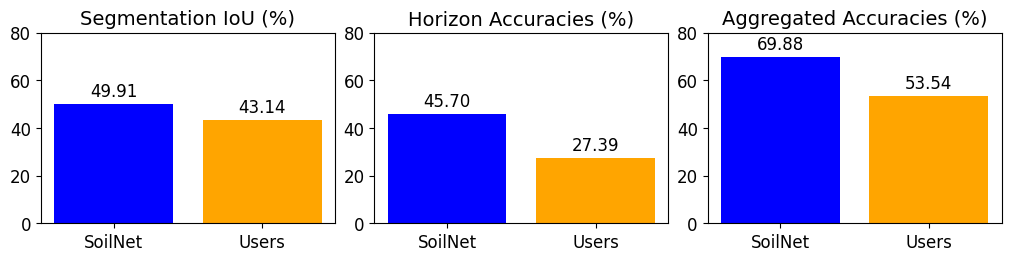

In [67]:
ious = {
    'SoilNet': 49.91,
    'Users' : 43.14
}
full_accuracies = {
    'SoilNet': 45.7,
    'Users' : 27.39
}
main_accuracies = {
    'SoilNet': 69.88,
    'Users' : 53.54
}

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(10, 2.5), constrained_layout=True)
colors = ['blue', 'orange']

ylim = 80
for ax, data, title in zip(
    axes,
    [ious, full_accuracies, main_accuracies],
    ['Segmentation IoU (%)', 'Horizon Accuracies (%)', 'Aggregated Accuracies (%)']
):
    keys = list(data.keys())
    vals = list(data.values())
    ax.bar(keys, vals, color=colors)
    ax.set_title(title)
    ax.title.set_fontsize(14)
    ax.set_ylim(0, ylim)
    ax.tick_params(axis='both', which='major', labelsize=12)
    # annotate bars
    for i, v in enumerate(vals):
        ax.text(i, v + ylim * 0.02, f"{v:.2f}", ha='center', va='bottom', fontsize=12)

pdf_path = 'sample_images/summary_metrics.pdf'
plt.savefig(pdf_path, dpi=300, bbox_inches="tight")
plt.show()

In [74]:
df[(df['anonId'] == '4b5d3eac-33f7-4e19-83f6-b91e55f6b578') & (~df['skipped'])]

,time_stamp,image_idx,image_name,anonId,skipped,depths,symbols
id,,,,,,,
182,2025-11-25 13:46:57.923108,661,TH_3177_Y_1.JPG,4b5d3eac-33f7-4e19-83f6-b91e55f6b578,False,[],[Mc]
183,2025-11-25 13:48:40.229118,411,NI_6135_Y_1.JPG,4b5d3eac-33f7-4e19-83f6-b91e55f6b578,False,"[0.2507931795987216, 0.4755406466397372]","[Ap, Sw-Bv, Sd]"
184,2025-11-25 13:49:42.072686,280,MV_0416_Y_1.JPG,4b5d3eac-33f7-4e19-83f6-b91e55f6b578,False,[0.5677123503251509],"[M., lC]"
185,2025-11-25 13:50:22.047935,58,BW_4552_Y_1.JPG,4b5d3eac-33f7-4e19-83f6-b91e55f6b578,False,[0.20786384235728872],"[Ap, Sd]"
186,2025-11-25 13:50:50.394627,586,SN_3388_Y_1.JPG,4b5d3eac-33f7-4e19-83f6-b91e55f6b578,False,[0.14220731908624823],"[Ah, Bv]"
187,2025-11-25 13:51:40.673947,288,MV_0478_Y_1.JPG,4b5d3eac-33f7-4e19-83f6-b91e55f6b578,False,"[0.3088739048350941, 0.4957426071166992, 0.596...","[Ah, Bv, E., Bt]"
188,2025-11-25 13:53:02.388595,463,NW_2697_Y_1.JPG,4b5d3eac-33f7-4e19-83f6-b91e55f6b578,False,[],[Ah-Bv]
189,2025-11-25 13:54:57.564202,665,TH_3254_Y_1.JPG,4b5d3eac-33f7-4e19-83f6-b91e55f6b578,False,[0.4515506625175476],"[Ah, Bv]"
190,2025-11-25 13:55:34.371109,104,BY_3647_Y_1.JPG,4b5d3eac-33f7-4e19-83f6-b91e55f6b578,False,[],[Axh]


In [76]:
# Find distinct users and number of annotations in the dataset
distinct_users = df_non_skipped['anonId'].nunique()
annotations_per_user = df_non_skipped.groupby('anonId').size()
print(f"Distinct users: {distinct_users}")
print("Annotations per user:")
print(annotations_per_user)

print("Average annotations per user:", annotations_per_user.mean())
print("Q25 annotations per user:", annotations_per_user.quantile(0.25))
print("Median annotations per user:", annotations_per_user.median())
print("Q75 annotations per user:", annotations_per_user.quantile(0.75))

Distinct users: 15
Annotations per user:
anonId
031d3b2d-e697-4339-a80d-6ad5d76de91f     1
2ab9dd0b-70c5-454c-aca6-414e1802b0f9     1
4b5d3eac-33f7-4e19-83f6-b91e55f6b578    47
4bfccfa8-02f8-4ffe-907c-35e836fe46b1     3
52f0815d-26b9-4973-8074-97f587625f8a     7
5cfcc301-8fda-40ee-967e-7655283c8cd4     9
729f9836-70b7-4119-b4b7-f0d9d3e3702b     3
89138847-ac09-4a58-9912-b308d7ac5f7f    18
99eff31c-15dc-407a-8bc0-ac4bf3581436     2
aa4bc528-5f3b-4d19-9b10-9f6d00356edb     4
bedaf05b-d9c4-4566-8b5c-832269dd9a12     2
c4b6847e-9fc6-4110-aaa4-9a17366170dc     1
d595d4f6-a471-45d8-b939-414bb0184e8b     5
dcda5e0e-e629-4133-9763-f7944f132b66     1
user-123                                 1
dtype: int64
Average annotations per user: 7.0
Q25 annotations per user: 1.0
Median annotations per user: 3.0
Q75 annotations per user: 6.0
